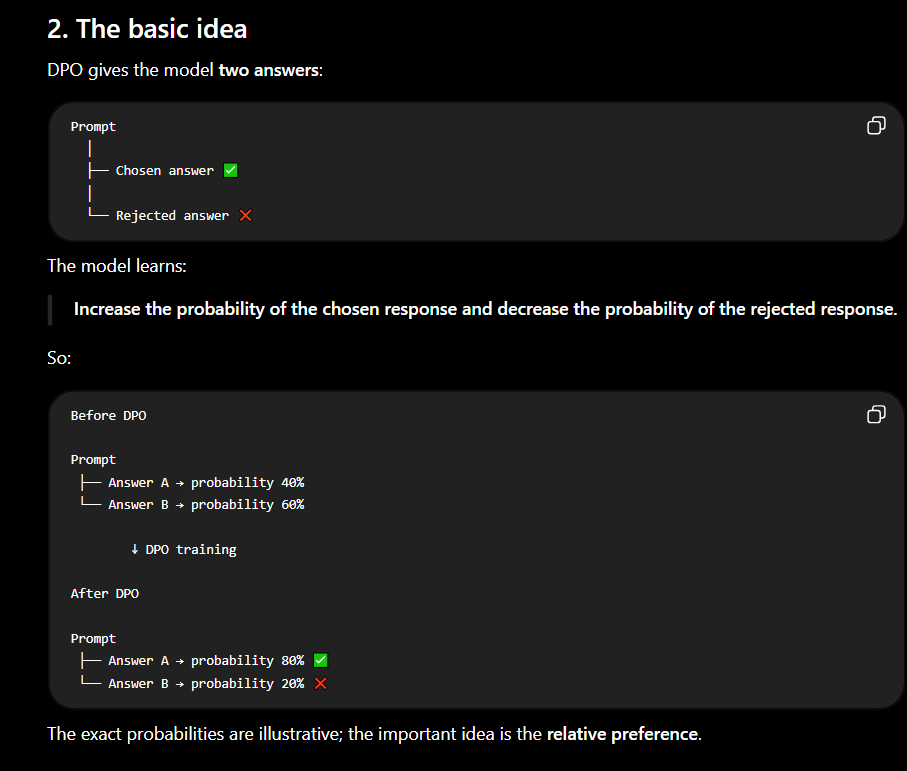
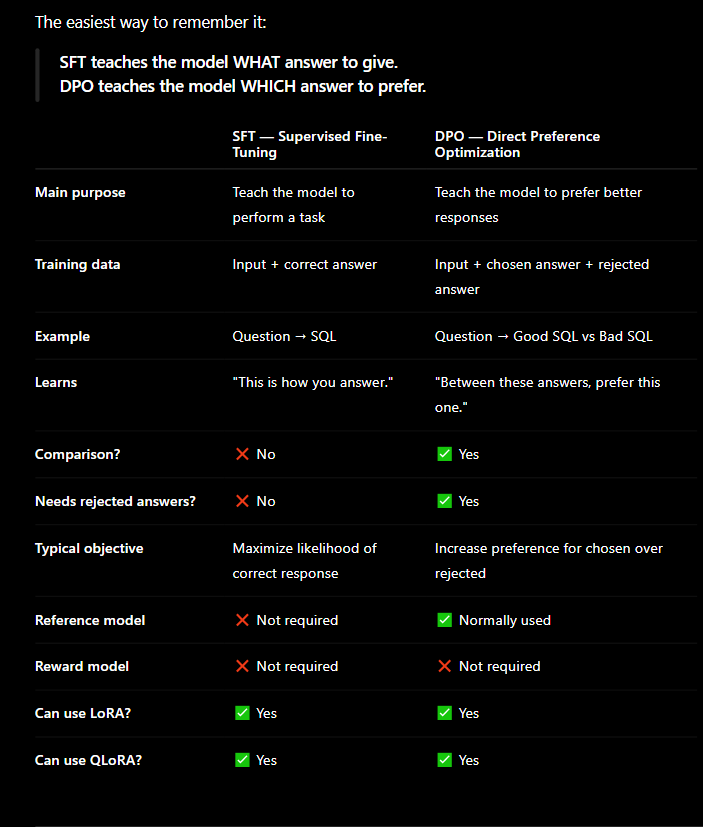


In [1]:
!pip install -q unsloth trl datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.3/81.3 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.1/26.1 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.3/199.3 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.7/146.7 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 69.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 76.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 111.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.

In [2]:
from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/Qwen3-0.6B",
    max_seq_length=1024,
    load_in_4bit=True,
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.9.14: Fast Qwen3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu130. CUDA: 7.5. CUDA Toolkit: 13.0. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

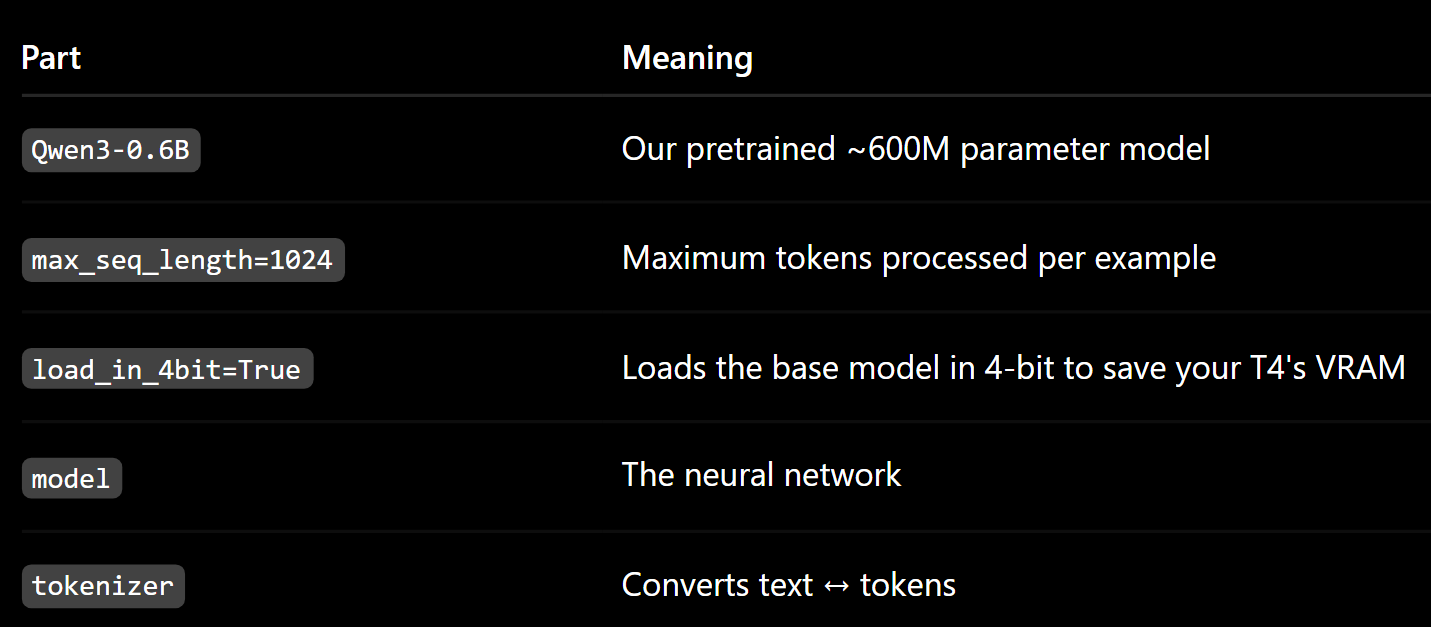

In [3]:
from datasets import load_dataset

dataset = load_dataset("jk200201/spider-dpo-1040")

print(dataset)

README.md:   0%|          | 0.00/7.65k [00:00<?, ?B/s]

dpo_data.json:   0%|          | 0.00/1.86M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1040 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['instruction', 'input', 'chosen', 'rejected'],
        num_rows: 1040
    })
})


In [4]:
print(dataset["train"].column_names)

['instruction', 'input', 'chosen', 'rejected']


In [5]:
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    lora_alpha=16,
    lora_dropout=0,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
    ],
)

Not an error, but Unsloth cannot patch MLP layers with our manual autograd engine since either LoRA adapters
are not enabled or a bias term (like in Qwen) is used.
Unsloth 2026.9.14 patched 28 layers with 28 QKV layers, 28 O layers and 0 MLP layers.


In [11]:
def create_prompt(example):
    return {
        "prompt": example["instruction"] + "\n" + example["input"]
    }

dataset = dataset.map(create_prompt)

Map:   0%|          | 0/1040 [00:00<?, ? examples/s]

In [14]:
from trl import DPOTrainer, DPOConfig

trainer = DPOTrainer(
    model=model,
    ref_model=None,
    train_dataset=dataset["train"],
    processing_class=tokenizer,

    args=DPOConfig(
        output_dir="dpo_outputs",
        max_length=1024,
        max_prompt_length=512,

        per_device_train_batch_size=2,
        gradient_accumulation_steps=4,

        learning_rate=5e-5,
        num_train_epochs=1,

        logging_steps=10,

        fp16=True,
        optim="adamw_8bit",

        report_to="none",
    ),
)

Extracting prompt in train dataset (num_proc=2):   0%|          | 0/1040 [00:00<?, ? examples/s]

Applying chat template to train dataset (num_proc=2):   0%|          | 0/1040 [00:00<?, ? examples/s]

Tokenizing train dataset (num_proc=2):   0%|          | 0/1040 [00:00<?, ? examples/s]

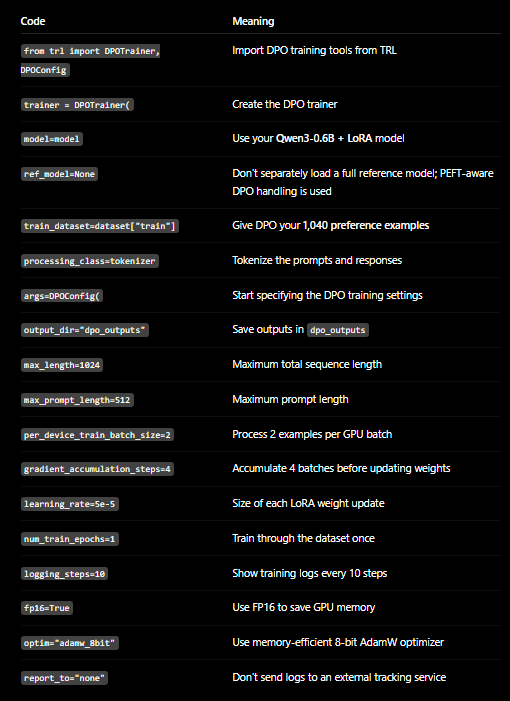


In [15]:
trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,040 | Num Epochs = 1 | Total steps = 130
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 4,587,520 of 600,637,440 (0.76% trained)


Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.
Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,rewards / chosen,rewards / rejected,rewards / accuracies,rewards / margins,logps / chosen,logps / rejected,logits / chosen,logits / rejected
10,0.678226,-0.001596,-0.032713,0.550000,0.031117,-77.832390,-68.244400,-1.994228,-2.192907
20,0.555913,-0.050464,-0.441619,0.750000,0.391154,-76.324867,-73.266350,-1.865374,-2.003467
30,0.518067,-0.501631,-1.123477,0.737500,0.621846,-76.706253,-78.500519,-1.844598,-1.906884
40,0.395255,-0.577424,-1.775883,0.862500,1.198459,-82.073196,-82.665794,-1.697238,-1.762356
50,0.326780,-0.900021,-2.584803,0.937500,1.684782,-82.411003,-92.103119,-1.578271,-1.694342
60,0.389824,-2.014749,-4.116693,0.850000,2.101943,-89.574646,-108.421616,-1.585874,-1.670149
70,0.452391,-2.471914,-5.694100,0.825000,3.222187,-101.121414,-131.064911,-1.487684,-1.589335
80,0.332394,-2.667901,-5.558190,0.875000,2.890289,-99.898170,-125.229393,-1.531544,-1.666489
90,0.396941,-2.616186,-4.718205,0.800000,2.102019,-89.936913,-107.089767,-1.548069,-1.609176
100,0.313314,-2.529688,-4.870297,0.837500,2.340609,-96.214661,-115.723244,-1.572755,-1.640917


Unsloth: Restored added_tokens_decoder metadata in dpo_outputs/checkpoint-130/tokenizer_config.json.


TrainOutput(global_step=130, training_loss=0.4245911561525785, metrics={'train_runtime': 676.4391, 'train_samples_per_second': 1.537, 'train_steps_per_second': 0.192, 'total_flos': 0.0, 'train_loss': 0.4245911561525785, 'epoch': 1.0})

In [21]:
FastLanguageModel.for_inference(model)

for i in range(5):

    example = dataset["train"][i]

    messages = [
        {
            "role": "user",
            "content": example["prompt"]
        }
    ]

    inputs = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt"
    ).to("cuda")

    outputs = model.generate(
        inputs,
        max_new_tokens=400,
        do_sample=False
    )

    generated = tokenizer.decode(
        outputs[0][inputs.shape[-1]:],
        skip_special_tokens=True
    )

    print("\n" + "=" * 80)
    print("EXAMPLE:", i)

    print("\nEXPECTED:")
    print(example["chosen"])

    print("\nGENERATED:")
    print(generated)

Both `max_new_tokens` (=400) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=400) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



EXAMPLE: 0

EXPECTED:
SELECT "Song_Name", "Song_release_year" FROM "singer" WHERE "Age" = (SELECT MIN("Age") FROM "singer");

GENERATED:
<think>
Okay, let's see. The user wants to find the name and release year of the song by the youngest singer. The database schema has a singer table, so I need to look into that. The question is about a singer's song, so I should check the singer_in_concert table because that connects singers to concerts, and then the concerts have a stadium ID. The stadium table has the singer's info. 

Wait, the singer_in_concert table has concert_ID and Singer_ID. So the singer's ID is in that table. The question is about the song by the youngest singer. So the singer's song is in the concert table. But the concert table has the stadium ID, which is linked to the stadium table. The stadium table has the singer's info. So the singer's data is in the singer table. 

So the steps are: find the singer with the youngest age, then get their song's release year. But how 

Both `max_new_tokens` (=400) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



EXAMPLE: 1

EXPECTED:
select max(capacity), average from stadium

GENERATED:
<think>
Okay, let's see. The user wants to find the maximum capacity and the average of all stadiums. They need the SQL query without any explanation. 

First, I need to look at the database schema. The stadiums table has columns Stadium_ID, Location, Name, Capacity, Highest, Lowest, and the primary key is Stadium_ID. So, the maximum capacity would be the highest value in that table. 

The average of all stadiums would be the average of all the capacity values. But wait, the question says "average of all stadiums". So, I need to calculate the average of all the capacities. 

So, the SQL query would select the maximum capacity and the average of all capacities. But how to write that in SQL. The SELECT statement would select the maximum and average. But the question says "return only the SQL query". So, the answer is the query that selects those two values. 

Wait, the question says "convert the following natur

Both `max_new_tokens` (=400) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



EXAMPLE: 2

EXPECTED:
select max(capacity), average from stadium

GENERATED:
<think>
Okay, let's see. The user wants to find the maximum capacity and the average of all stadiums. They need the SQL query without any explanation. 

First, I need to look at the database schema. The stadiums table has columns Stadium_ID, Location, Name, Capacity, Highest, Lowest, and the primary key is Stadium_ID. So, the maximum capacity would be the highest value in that table. 

The average of all stadiums would be the average of all the capacity values. But wait, the question says "average of all stadiums". So, I need to calculate the average of all the capacities. 

So, the SQL query would select the maximum capacity and the average of all capacities. But how to write that in SQL. The SELECT statement would select the maximum and average. But the question says "return only the SQL query". So, the answer is the query that selects those two values. 

Wait, the question says "convert the following natur

Both `max_new_tokens` (=400) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



EXAMPLE: 3

EXPECTED:
SELECT T2.name ,  count(*) FROM concert AS T1 JOIN stadium AS T2 ON T1.stadium_id  =  T2.stadium_id GROUP BY T1.stadium_id

GENERATED:
<think>
Okay, let's see. The user wants to show the stadium name and the number of concerts in each stadium. They also want the SQL query without any explanation. 

First, I need to look at the database schema. The stadium table has a stadium_id, location, name, capacity, highest, lowest, average, and the primary key is stadium_id. The singer table has singer_id, name, country, song name, release year, age, is_male. The concert table has concert_id, concert name, theme, stadium_id, year, and the stadium_id is a foreign key to the stadium table. The singer_in_concert table has concert_id and singer_id as primary keys, with concert_id referencing concert and singer_id referencing singer.

So the question is asking for the stadium name and the number of concerts per stadium. The stadium name is in the name column of the stadium table